# LSEG Daily Returns: Euro500

Ziel dieses Notebooks:
- Daily Returns fuer alle Aktien im `euro500` Portfolio ziehen
- Identifier-Fallback robust halten: alle historischen ISIN/RIC je `firm_id`
- Cache **pro Unternehmen (`firm_id`)** statt pro Quartal
- Finale Tabelle nur fuer Tage, an denen die Aktie im Index ist (exakte Mitgliedschaft)


## 0. Setup und Input-Daten laden

- Pfade/Parameter setzen
- `euro500.parquet` laden
- Datentypen bereinigen und `firm_id` als verpflichtenden Schluessel nutzen


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning, module="lseg")
pd.set_option("display.max_columns", 120)

from project_paths import BASE_DIR, DATA_DIR, CACHE_DATA_DIR, GRAPH_DIR
NB_GRAPH_DIR = GRAPH_DIR / "LSEG_DataPull_DailyReturns"
NB_GRAPH_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR = NB_GRAPH_DIR

CACHE_DIR = CACHE_DATA_DIR / "daily_returns_cache_by_company"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

MANIFEST_PATH = CACHE_DATA_DIR / "daily_returns_company_cache_manifest.parquet"
OUTPUT_RETURNS_ALL = DATA_DIR / "daily_returns_company_all.parquet"
OUTPUT_DAILY_RETURNS_EURO500 = DATA_DIR / "euro500_daily_returns.parquet"
OUTPUT_MISSING = DATA_DIR / "daily_returns_missing_companies.parquet"
LEGACY_RETURNS_PATH = DATA_DIR / "rets_daily_isin.parquet"
BAD_IDS_PATH = CACHE_DATA_DIR / "daily_returns_bad_ids.csv"
STEP_ROWS_PATH = CACHE_DATA_DIR / "daily_returns_step_rows.parquet"
STEP_CKPT_PATH = CACHE_DATA_DIR / "daily_returns_step_checkpoint.json"

TARGET_END_DATE = pd.Timestamp("2025-12-31")
BETA_LOOKBACK_MONTHS = 6

EURO500_PATH = DATA_DIR / "euro500.parquet"
if not EURO500_PATH.exists():
    raise FileNotFoundError(f"File not found: {EURO500_PATH}")

df = pd.read_parquet(EURO500_PATH).copy()

## 1. Mitgliedschaftszeiträume je Quartal bestimmen

Mitgliedschaft pro Zeile gilt von `effective_date` bis einen Tag vor naechster `effective_date`.

from matplotlib.ticker import MaxNLocator


from matplotlib.ticker import MultipleLocator



In [2]:
quarter_calendar = (
    df[["quarter", "effective_date"]]
    .dropna()
    .drop_duplicates()
    .sort_values("effective_date")
    .reset_index(drop=True)
)
quarter_calendar["next_effective_date"] = quarter_calendar["effective_date"].shift(-1)

# Ende inklusiv: Tag vor naechster effective_date, hart gekappt auf TARGET_END_DATE.
max_end = TARGET_END_DATE
quarter_calendar["membership_end_date"] = quarter_calendar["next_effective_date"] - pd.Timedelta(days=1)
quarter_calendar["membership_end_date"] = quarter_calendar["membership_end_date"].fillna(max_end)
quarter_calendar["membership_end_date"] = quarter_calendar["membership_end_date"].clip(upper=max_end)

membership = df.merge(
    quarter_calendar[["quarter", "effective_date", "membership_end_date"]],
    on=["quarter", "effective_date"],
    how="left",
)

# Avoid duplicate date-column names from upstream inputs.
membership = membership.drop(columns=[c for c in ["start_date", "end_date"] if c in membership.columns])
membership["start_date"] = membership["effective_date"]
membership["end_date"] = membership["membership_end_date"]
membership = membership.drop(columns=["membership_end_date"])

membership = membership.dropna(subset=["firm_id", "start_date", "end_date"]).copy()
membership = membership[membership["start_date"] <= membership["end_date"]].copy()

print("Membership rows:", len(membership))
print("Membership companies:", membership["firm_id"].nunique())
print("Date range:", membership["start_date"].min().date(), "to", membership["end_date"].max().date())


Membership rows: 56000
Membership companies: 1245
Date range: 1998-01-01 to 2025-12-31


## 2. Cache- und Pull-Funktionen definieren

- Ein Cache-File pro `firm_id`
- Bei vorhandenem Cache nur fehlende Datumssegmente nachladen


In [3]:
def load_legacy_returns(path: Path) -> pd.DataFrame:
    """
    Normalize existing returns file (rets_daily_isin.parquet) to:
    date | pull_id | id_type | ret
    """
    if not path.exists():
        return pd.DataFrame(columns=["date", "pull_id", "id_type", "ret"])

    raw = pd.read_parquet(path).copy()

    date_col = "date" if "date" in raw.columns else None
    if date_col is None:
        for c in raw.columns:
            if "date" in str(c).lower():
                date_col = c
                break
    if date_col is None:
        return pd.DataFrame(columns=["date", "pull_id", "id_type", "ret"])

    id_col = None
    for c in ["ISIN", "isin", "Isin"]:
        if c in raw.columns:
            id_col = c
            break
    if id_col is None:
        return pd.DataFrame(columns=["date", "pull_id", "id_type", "ret"])

    if "ret" in raw.columns:
        ret = pd.to_numeric(raw["ret"], errors="coerce")
    elif "value" in raw.columns:
        v = pd.to_numeric(raw["value"], errors="coerce")
        abs_q99 = np.nanpercentile(np.abs(v.dropna()), 99) if v.notna().any() else np.nan
        ret = v / 100.0 if np.isfinite(abs_q99) and abs_q99 > 1.5 else v
    else:
        return pd.DataFrame(columns=["date", "pull_id", "id_type", "ret"])

    out = pd.DataFrame(
        {
            "date": pd.to_datetime(raw[date_col], errors="coerce"),
            "pull_id": raw[id_col].astype("string").str.strip(),
            "id_type": "ISIN",
            "ret": ret,
        }
    )
    out.loc[out["pull_id"] == "", "pull_id"] = pd.NA
    out = out.dropna(subset=["date", "pull_id", "ret"]).copy()
    out = out.sort_values(["pull_id", "date"]).drop_duplicates(["pull_id", "date"], keep="last")
    return out.reset_index(drop=True)


## 3. Pull-Universum je Firma erstellen

- Pro `firm_id` Pull-Zeitraum bestimmen (inkl. Beta-Lookback)
- Historische Identifier-Liste je Firma aufbauen (ISIN -> RIC_current -> RIC)


In [4]:
from lseg_series_puller import build_company_candidates

company_base = (
    membership[["firm_id"]]
    .dropna(subset=["firm_id"])
    .drop_duplicates(subset=["firm_id"])
    .reset_index(drop=True)
)

# Pull-Zeitraum aus Mitgliedschaftsfenstern je Unternehmen
span = (
    membership.groupby("firm_id", as_index=False)
    .agg(start_date=("start_date", "min"), end_date=("end_date", "max"))
)
span["start_date"] = span["start_date"] - pd.DateOffset(months=BETA_LOOKBACK_MONTHS)
company_pull_map = company_base.merge(span, on="firm_id", how="left")

# Unternehmens-Metadaten fuer bessere Missing-Analyse
meta_cols = [
    c for c in ["firm_id", "name", "ISIN", "RIC", "RIC_current", "hq_country", "hq_code"]
    if c in membership.columns
]
company_meta = (
    membership[meta_cols]
    .dropna(subset=["firm_id"])
    .drop_duplicates(subset=["firm_id"], keep="first")
    .rename(columns={"name": "company_name"})
)
company_pull_map = company_pull_map.merge(company_meta, on="firm_id", how="left")

company_candidates_map = {}
for ck, g in membership.groupby("firm_id", sort=False):
    if pd.isna(ck):
        continue
    # build_company_candidates expects one unique date column.
    g_req = g.copy()
    if "start_date" in g_req.columns:
        g_req["_candidate_date"] = pd.to_datetime(g_req["start_date"], errors="coerce")
    elif "date" in g_req.columns:
        g_req["_candidate_date"] = pd.to_datetime(g_req["date"], errors="coerce")
    elif "effective_date" in g_req.columns:
        g_req["_candidate_date"] = pd.to_datetime(g_req["effective_date"], errors="coerce")
    else:
        g_req["_candidate_date"] = pd.NaT

    g_req = g_req.drop(columns=[c for c in ["date"] if c in g_req.columns], errors="ignore")
    g_req = g_req.rename(columns={"_candidate_date": "date"})
    company_candidates_map[str(ck)] = build_company_candidates(g_req)

company_pull_map["id_candidates"] = company_pull_map["firm_id"].astype("string").map(
    lambda ck: company_candidates_map.get(str(ck), [])
)
company_pull_map["n_id_candidates"] = company_pull_map["id_candidates"].apply(len)

legacy_returns = load_legacy_returns(LEGACY_RETURNS_PATH)
legacy_by_id = {}
if not legacy_returns.empty:
    for (id_type, pull_id), g in legacy_returns.groupby(["id_type", "pull_id"], dropna=False):
        legacy_by_id[(id_type, pull_id)] = g[["date", "ret"]].copy()

print("Companies to process:", len(company_pull_map))
print("Legacy rows loaded:", len(legacy_returns))
print("Legacy ids loaded  :", len(legacy_by_id))
print("ID candidates stats:", company_pull_map["n_id_candidates"].describe(), sep="\n")
print(company_pull_map[["firm_id", "n_id_candidates"]].head(3))




Companies to process: 1245
Legacy rows loaded: 0
Legacy ids loaded  : 0
ID candidates stats:
count    1245.000000
mean        2.616064
std         0.862062
min         2.000000
25%         2.000000
50%         2.000000
75%         3.000000
max         8.000000
Name: n_id_candidates, dtype: float64
       firm_id  n_id_candidates
0  FIRM0000557                2
1  FIRM0000171                2
2  FIRM0000351                4


## 4. Returns ziehen und Dateien speichern

- Cache/Seed-Abdeckung je `firm_id` pruefen
- Nur fehlende Segmente aus LSEG nachladen (Fallback ueber Kandidaten)
- Outputs schreiben: Manifest, `daily_returns_company_all`, `daily_returns_missing_companies` (optional)


In [5]:
# Step 5 — Daily Returns Pull via Standard Series Puller (lean version)

from lseg_series_puller import DailyReturnsPullConfig, run_standard_pull

force_refresh = False
SKIP_LSEG_PULL = False
CHECKPOINT_EVERY_N_PULLS = 25
PULL_ABORT_ON_RATE_LIMIT = True
SKIP_KNOWN_BAD_IDS = True

cfg = DailyReturnsPullConfig(
    target_end_date=TARGET_END_DATE,
    force_refresh=force_refresh,
    skip_lseg_pull=SKIP_LSEG_PULL,
    checkpoint_every_n_pulls=CHECKPOINT_EVERY_N_PULLS,
    skip_known_bad_ids=SKIP_KNOWN_BAD_IDS,
    pull_abort_on_rate_limit=PULL_ABORT_ON_RATE_LIMIT,
)

stats = run_standard_pull(
    pull_type='daily_returns',
    company_pull_map=company_pull_map,
    legacy_by_id=legacy_by_id,
    cache_dir=CACHE_DIR,
    manifest_path=MANIFEST_PATH,
    output_returns_all=OUTPUT_RETURNS_ALL,
    output_missing=OUTPUT_MISSING,
    bad_ids_path=BAD_IDS_PATH,
    step_rows_path=STEP_ROWS_PATH,
    step_ckpt_path=STEP_CKPT_PATH,
    config=cfg,
)

print('Standard pull stats:', stats)

# Backward-compatible in-memory variable for later notebook cells
if OUTPUT_MISSING.exists():
    missing_df = pd.read_parquet(OUTPUT_MISSING).copy()
else:
    missing_df = pd.DataFrame(columns=["firm_id", "company_name", "ISIN", "RIC", "RIC_current"])


Standard Series Pull Overview
series_specs: ret<-['TR.TotalReturn','PCTCHNG','TR.PriceClose','TRDPRC_1']
request_rows: 1,245
coverage: all_companies=1,245 | full_coverage=595 | partial_coverage=629 | bad_ids=21 | remaining=0
mode: CACHE+NETWORK | batch_size: 10
Saved manifest: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/cache/daily_returns_company_cache_manifest.parquet
Saved company returns: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/daily_returns_company_all.parquet rows: 3990812
Built missing list in-memory rows: 0
Updated bad-id log: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/cache/daily_returns_bad_ids.csv rows: 21
Saved step rows: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/cache/daily_returns_step_rows.parquet rows: 1223
Saved step checkpoint: /Users/jakob/Documents/Parforceleistung/Studium

## 5. Exakt auf Index-Mitgliedschaft filtern

`returns_in_index` enthaelt nur Tage, an denen die Aktie im Portfolio/Index enthalten war.


In [6]:
# Expand membership windows to business days for exact day-level filter
m_cols = [
    c for c in ["quarter", "start_date", "end_date", "firm_id", "name", "ISIN", "RIC", "RIC_current"]
    if c in membership.columns
]
m = membership[m_cols].copy()

m = m.dropna(subset=["firm_id", "start_date", "end_date"]).copy()

parts = []
for _, r in m.iterrows():
    dates = pd.bdate_range(r["start_date"], r["end_date"], freq="B")
    if len(dates) == 0:
        continue
    part = pd.DataFrame({"date": dates})
    for c in m_cols:
        if c in {"start_date", "end_date"}:
            continue
        part[c] = r[c]
    parts.append(part)

if parts:
    membership_daily = pd.concat(parts, ignore_index=True)
else:
    membership_daily = pd.DataFrame(columns=["date", "quarter", "firm_id", "name"])

returns_all = pd.read_parquet(OUTPUT_RETURNS_ALL)
returns_all["date"] = pd.to_datetime(returns_all["date"], errors="coerce")
returns_all = returns_all[returns_all["date"] <= TARGET_END_DATE].copy()

ret_cols = [c for c in ["date", "firm_id", "ret", "pull_id"] if c in returns_all.columns]
returns_in_index = membership_daily.merge(
    returns_all[ret_cols],
    on=["date", "firm_id"],
    how="left",
    suffixes=("", "_ret"),
)

# keep only dates where we actually have a return
returns_in_index = returns_in_index.dropna(subset=["ret"]).copy()

returns_in_index = returns_in_index.sort_values(["date", "firm_id"]).reset_index(drop=True)

returns_in_index.to_parquet(OUTPUT_DAILY_RETURNS_EURO500, index=False)

print("Built in-index daily returns")
print("Saved:", OUTPUT_DAILY_RETURNS_EURO500)
print("Rows:", len(returns_in_index))
print("Companies covered:", returns_in_index["firm_id"].nunique())
print("Date range:", returns_in_index["date"].min(), "to", returns_in_index["date"].max())


Built in-index daily returns
Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/euro500_daily_returns.parquet
Rows: 3457796
Companies covered: 1211
Date range: 1998-01-02 00:00:00 to 2025-12-31 00:00:00


## 6. Datenabdeckung prüfen

Dieser Block zeigt nur das Wesentliche:
- kompakte KPI-Zusammenfassung zur Coverage
- Verlauf der Coverage-Quote je Quartal
- aufgeteilte Anzahl `abgedeckt` vs. `fehlend` je Quartal


                     metric            value
          Quarters analyzed              108
          Mean coverage (%)            99.36
        Median coverage (%)             99.6
    Quarters < 95% coverage                0
 Worst quarter (coverage %)  2002Q3 (97.40%)
Latest quarter (coverage %) 2025Q4 (100.00%)
   Latest missing companies                0


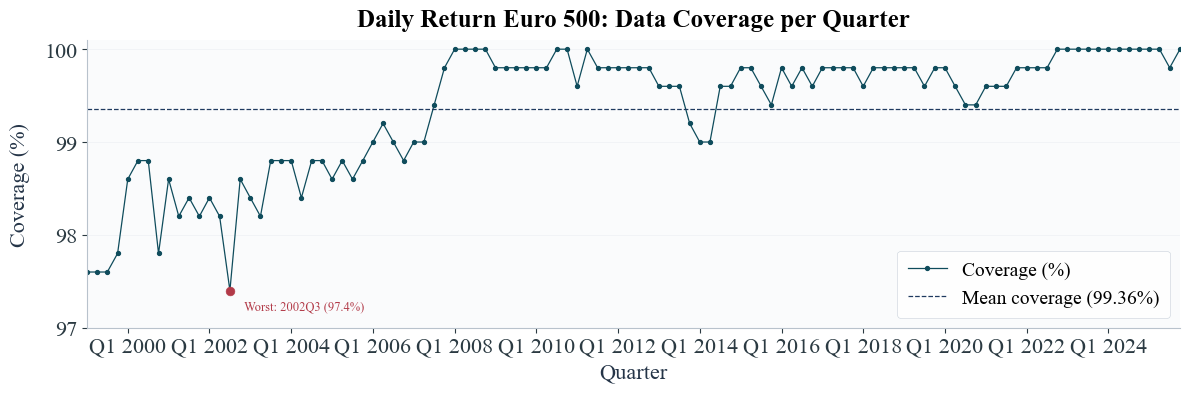

In [7]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from plot_style import COLORS, set_global_plot_style, style_axes, style_legend, style_time_axis, save_figure
set_global_plot_style()

if "returns_in_index" in locals():
    returns_in_index = returns_in_index.copy()
else:
    if not OUTPUT_DAILY_RETURNS_EURO500.exists():
        raise FileNotFoundError(f"File not found: {OUTPUT_DAILY_RETURNS_EURO500}. Run Step 6 first.")
    returns_in_index = pd.read_parquet(OUTPUT_DAILY_RETURNS_EURO500).copy()

returns_in_index["date"] = pd.to_datetime(returns_in_index["date"], errors="coerce")
returns_in_index["quarter"] = returns_in_index["quarter"].astype("string")

# Erwartete Firmenzahl je Quartal aus dem Universe
universe_q = (
    df.groupby("quarter", as_index=False)
    .agg(n_members=("firm_id", "nunique"))
)
universe_q["quarter"] = universe_q["quarter"].astype("string")

coverage_q = (
    returns_in_index
    .groupby("quarter", as_index=False)
    .agg(
        n_obs=("ret", "size"),
        n_companies=("firm_id", "nunique"),
        n_dates=("date", "nunique"),
    )
    .merge(universe_q, on="quarter", how="right")
)

coverage_q["n_obs"] = coverage_q["n_obs"].fillna(0).astype(int)
coverage_q["n_companies"] = coverage_q["n_companies"].fillna(0).astype(int)
coverage_q["n_dates"] = coverage_q["n_dates"].fillna(0).astype(int)
coverage_q["n_members"] = coverage_q["n_members"].fillna(0).astype(int)

coverage_q["missing_companies"] = (coverage_q["n_members"] - coverage_q["n_companies"]).clip(lower=0)
coverage_q["coverage_pct"] = np.where(
    coverage_q["n_members"] > 0,
    100.0 * coverage_q["n_companies"] / coverage_q["n_members"],
    np.nan,
)
coverage_q["avg_obs_per_company"] = np.where(
    coverage_q["n_companies"] > 0,
    coverage_q["n_obs"] / coverage_q["n_companies"],
    np.nan,
)
coverage_q["quarter_end"] = pd.PeriodIndex(coverage_q["quarter"].astype(str), freq="Q").to_timestamp(how="end")
QA_END_QUARTER = pd.Period("2025Q4", freq="Q")
coverage_q["quarter_period"] = pd.PeriodIndex(coverage_q["quarter"].astype(str), freq="Q")
coverage_q = coverage_q[coverage_q["quarter_period"] <= QA_END_QUARTER].copy()
coverage_q = coverage_q[coverage_q["quarter_end"] >= pd.Timestamp("1999-01-01")].copy()
coverage_q = coverage_q.sort_values("quarter_end").reset_index(drop=True)

coverage_q["quarter_label_pretty"] = (
    "Q"
    + coverage_q["quarter_period"].dt.quarter.astype(str)
    + " "
    + coverage_q["quarter_period"].dt.year.astype(str)
)

if coverage_q.empty:
    raise ValueError("coverage_q is empty. Check returns_in_index construction and universe input.")

worst_idx = coverage_q["coverage_pct"].idxmin()
worst = coverage_q.loc[worst_idx]
latest = coverage_q.iloc[-1]
mean_cov = float(coverage_q["coverage_pct"].mean())

kpi = pd.DataFrame(
    {
        "metric": [
            "Quarters analyzed",
            "Mean coverage (%)",
            "Median coverage (%)",
            "Quarters < 95% coverage",
            "Worst quarter (coverage %)",
            "Latest quarter (coverage %)",
            "Latest missing companies",
        ],
        "value": [
            int(len(coverage_q)),
            round(float(coverage_q["coverage_pct"].mean()), 2),
            round(float(coverage_q["coverage_pct"].median()), 2),
            int((coverage_q["coverage_pct"] < 95).sum()),
            f"{worst['quarter']} ({worst['coverage_pct']:.2f}%)",
            f"{latest['quarter']} ({latest['coverage_pct']:.2f}%)",
            int(latest["missing_companies"]),
        ],
    }
)
print(kpi.to_string(index=False))

fig, ax1 = plt.subplots(figsize=(12, 4))

# Plot 1: Coverage-Quote
ax1.plot(
    coverage_q["quarter_end"],
    coverage_q["coverage_pct"],
    color=COLORS["primary"],
    linewidth=0.9,
    marker="o",
    markersize=2.8,
    label="Coverage (%)",
)
ax1.axhline(mean_cov, color=COLORS["secondary"], linewidth=0.9, linestyle="--", label=f"Mean coverage ({mean_cov:.2f}%)")
ax1.fill_between(
    coverage_q["quarter_end"],
    coverage_q["coverage_pct"],
    97,
    where=coverage_q["coverage_pct"] < 97,
    color=COLORS["accent"],
    alpha=0.15,
)
ax1.scatter([worst["quarter_end"]], [worst["coverage_pct"]], color=COLORS["accent"], s=40, zorder=5)
ax1.annotate(
    f"Worst: {worst['quarter']} ({worst['coverage_pct']:.1f}%)",
    xy=(worst["quarter_end"], worst["coverage_pct"]),
    xytext=(10, -14),
    textcoords="offset points",
    color=COLORS["accent"],
    fontsize=9,
)
ax1.set_title("Daily Return Euro 500: Data Coverage per Quarter", fontsize=13, pad=10)
ax1.set_ylabel("Coverage (%)")
ax1.set_ylim(97, 100.1)
style_axes(ax1, grid_axis="y")
style_legend(ax1, loc="lower right", frameon=False)

tick_idx = coverage_q.index[
    (coverage_q["quarter_period"].dt.year >= 2000)
    & (coverage_q["quarter_period"].dt.quarter == 1)
    & (((coverage_q["quarter_period"].dt.year - 2000) % 2) == 0)
].tolist()
if not tick_idx:
    n_q = len(coverage_q)
    step_q = max(1, n_q // 14)
    tick_idx = list(range(0, n_q, step_q))

ax1.set_xticks(coverage_q["quarter_end"].iloc[tick_idx])
ax1.set_xticklabels(coverage_q["quarter_label_pretty"].iloc[tick_idx])
ax1.set_xlabel("Quarter")

step7_plot_path = TABLE_DIR / "lseg_dailyreturns_step7_qa_coverage.png"
plt.tight_layout()
save_figure(plt.gcf(), step7_plot_path, dpi=200)
plt.show()

## 7. Firmen mit den meisten Missing-Quartalen

Diese Zelle zeigt die 15 fehlenden Unternehmen mit den meisten Quartalen im EURO500-Universum als Tabelle.
Zusatzspalten: `sector` sowie `index_period` (von `first_quarter` bis `last_quarter`).



In [8]:
# Post-Processing only: keine LSEG-Session, kein neuer Datenpull
# NOTE: No additional files are written in this section.

missing_in = OUTPUT_MISSING
euro_in = EURO500_PATH

if not euro_in.exists():
    raise FileNotFoundError(f"euro500 file not found: {euro_in}")

euro = pd.read_parquet(euro_in).copy()

# Optional: pull-failure list (diagnostic only)
if "missing_df" in locals():
    missing_pull = missing_df.copy()
elif missing_in.exists():
    missing_pull = pd.read_parquet(missing_in).copy()
else:
    missing_pull = pd.DataFrame(columns=["firm_id", "company_name", "ISIN", "RIC", "RIC_current"])

for c in ["firm_id", "ISIN", "RIC", "RIC_current", "name", "quarter", "date", "trbc_sector", "Sector"]:
    if c in euro.columns:
        euro[c] = euro[c].astype("string").str.strip()
        euro.loc[euro[c] == "", c] = pd.NA

if "firm_id" not in euro.columns:
    raise ValueError("Column 'firm_id' missing in euro500 input.")

if "membership" not in locals():
    raise ValueError("'membership' not found. Run Step 2/4 before this cell.")

# Build expected in-index business-day panel from membership windows
m_cols = [c for c in ["firm_id", "start_date", "end_date", "quarter"] if c in membership.columns]
m = membership[m_cols].copy().dropna(subset=["firm_id", "start_date", "end_date"])
m["start_date"] = pd.to_datetime(m["start_date"], errors="coerce")
m["end_date"] = pd.to_datetime(m["end_date"], errors="coerce")
m = m.dropna(subset=["start_date", "end_date"])

parts = []
for _, r in m.iterrows():
    d = pd.bdate_range(r["start_date"], r["end_date"], freq="B")
    if len(d) == 0:
        continue
    p = pd.DataFrame({"date": d, "firm_id": r["firm_id"]})
    if "quarter" in m.columns:
        p["quarter"] = r["quarter"]
    parts.append(p)

if parts:
    expected_daily = pd.concat(parts, ignore_index=True).drop_duplicates(["date", "firm_id"])
else:
    expected_daily = pd.DataFrame(columns=["date", "firm_id", "quarter"])

returns_all = pd.read_parquet(OUTPUT_RETURNS_ALL).copy()
returns_all["date"] = pd.to_datetime(returns_all["date"], errors="coerce")
returns_all["firm_id"] = returns_all["firm_id"].astype("string").str.strip()
returns_all["ret"] = pd.to_numeric(returns_all["ret"], errors="coerce")
returns_all = returns_all.dropna(subset=["date", "firm_id", "ret"]).copy()
returns_all = returns_all[["date", "firm_id"]].drop_duplicates()

cov = expected_daily.merge(
    returns_all.assign(has_ret=1),
    on=["date", "firm_id"],
    how="left",
)

firm_cov = (
    cov.groupby("firm_id", as_index=False)["has_ret"]
    .agg(expected_days="size", found_days="sum")
)
firm_cov["found_days"] = firm_cov["found_days"].fillna(0).astype(int)
firm_cov["coverage_pct"] = 100.0 * firm_cov["found_days"] / firm_cov["expected_days"].where(firm_cov["expected_days"] > 0, np.nan)

# Missing definition: firm had in-index days but zero matched returns
missing = firm_cov.loc[firm_cov["found_days"] == 0, ["firm_id", "expected_days", "found_days", "coverage_pct"]].copy()

# Coverage + period per firm
agg_dict = {
    "n_quarters_in_index": ("quarter", "nunique"),
    "first_quarter": ("quarter", "min"),
    "last_quarter": ("quarter", "max"),
}
if "date" in euro.columns:
    euro["date"] = pd.to_datetime(euro["date"], errors="coerce")
    agg_dict["first_date"] = ("date", "min")
    agg_dict["last_date"] = ("date", "max")

firm_period = (
    euro[[c for c in ["firm_id", "quarter", "date"] if c in euro.columns]]
    .dropna(subset=["firm_id", "quarter"])
    .drop_duplicates()
    .groupby("firm_id", as_index=False)
    .agg(**agg_dict)
)

firm_period["index_period"] = (
    firm_period["first_quarter"].astype("string").fillna("")
    + " to "
    + firm_period["last_quarter"].astype("string").fillna("")
)

sector_col = "trbc_sector" if "trbc_sector" in euro.columns else ("Sector" if "Sector" in euro.columns else None)
meta_cols = ["firm_id", "name", "RIC", "RIC_current", "ISIN"]
if sector_col:
    meta_cols.append(sector_col)

meta = (
    euro[meta_cols]
    .dropna(subset=["firm_id"])
    .drop_duplicates(subset=["firm_id"], keep="first")
)

if sector_col and sector_col != "sector":
    meta = meta.rename(columns={sector_col: "sector"})
elif "sector" not in meta.columns:
    meta["sector"] = pd.NA

missing_enriched = (
    missing.merge(meta, on="firm_id", how="left")
    .merge(firm_period, on="firm_id", how="left")
)

ric_series = pd.Series(pd.NA, index=missing_enriched.index, dtype="string")
if "RIC_current" in missing_enriched.columns:
    ric_series = missing_enriched["RIC_current"].astype("string")
if "RIC" in missing_enriched.columns:
    ric_series = ric_series.fillna(missing_enriched["RIC"].astype("string"))

result = pd.DataFrame(
    {
        "name": missing_enriched["name"].astype("string") if "name" in missing_enriched.columns else pd.Series(pd.NA, index=missing_enriched.index, dtype="string"),
        "firmid": missing_enriched["firm_id"].astype("string"),
        "ric": ric_series,
        "isin": missing_enriched["ISIN"].astype("string") if "ISIN" in missing_enriched.columns else pd.Series(pd.NA, index=missing_enriched.index, dtype="string"),
        "sector": missing_enriched["sector"].astype("string") if "sector" in missing_enriched.columns else pd.Series(pd.NA, index=missing_enriched.index, dtype="string"),
        "n_quarters_in_index": missing_enriched["n_quarters_in_index"].fillna(0).astype(int) if "n_quarters_in_index" in missing_enriched.columns else 0,
        "expected_days": missing_enriched["expected_days"].fillna(0).astype(int),
        "coverage_pct": missing_enriched["coverage_pct"].astype(float),
        "first_quarter": missing_enriched["first_quarter"].astype("string") if "first_quarter" in missing_enriched.columns else pd.Series(pd.NA, index=missing_enriched.index, dtype="string"),
        "last_quarter": missing_enriched["last_quarter"].astype("string") if "last_quarter" in missing_enriched.columns else pd.Series(pd.NA, index=missing_enriched.index, dtype="string"),
        "index_period": missing_enriched["index_period"].astype("string") if "index_period" in missing_enriched.columns else pd.Series(pd.NA, index=missing_enriched.index, dtype="string"),
    }
)

result = (
    result
    .sort_values(["n_quarters_in_index", "expected_days", "name"], ascending=[False, False, True], na_position="last")
    .drop_duplicates(subset=["firmid"], keep="first")
    .head(15)
    .reset_index(drop=True)
)

partial_count = int(((firm_cov["found_days"] > 0) & (firm_cov["found_days"] < firm_cov["expected_days"])).sum())
full_count = int((firm_cov["found_days"] == firm_cov["expected_days"]).sum())

print(f"Missing firms total (0 matched returns on in-index days): {missing['firm_id'].nunique()}")
print(f"Partial coverage firms (0 < found < expected): {partial_count}")
print(f"Full coverage firms (found == expected): {full_count}")
print(f"Pull-failure list rows (diagnostic): {len(missing_pull)}")
print("Top 15 missing companies by quarters in index:")

try:
    display(result)
except NameError:
    print(result.to_string(index=False))



Missing firms total (0 matched returns on in-index days): 34
Partial coverage firms (0 < found < expected): 1204
Full coverage firms (found == expected): 7
Pull-failure list rows (diagnostic): 0
Top 15 missing companies by quarters in index:


,name,firmid,ric,isin,sector,n_quarters_in_index,expected_days,coverage_pct,first_quarter,last_quarter,index_period
0,BIP Investment Partners SA,FIRM0002718,LU0110790085.BR,LU0110790085,Financials,24,1565,0.0,2001Q1,2006Q4,2001Q1 to 2006Q4
1,Funkwerk AG,FIRM0000840,FEW0n.TG,DE0005753149,Technology,18,1175,0.0,2001Q2,2005Q3,2001Q2 to 2005Q3
2,Meta Wolf AG,FIRM0000633,WOLFG.DE,DE000A254203,Consumer Cyclicals,13,847,0.0,1998Q1,2001Q1,1998Q1 to 2001Q1
3,QBeyond AG,FIRM0002842,QBY0k.DE,DE000A41YDG0,Technology,11,714,0.0,2005Q1,2014Q1,2005Q1 to 2014Q1
4,Compania Espanola de Viviendas en Alquiler SA,FIRM0000547,CEV.MC,ES0132955008,Real Estate,10,652,0.0,1998Q1,2003Q2,1998Q1 to 2003Q2
5,Ls Invest AG,FIRM0000589,IFAG.H,DE0006131204,Consumer Cyclicals,10,652,0.0,1998Q1,2000Q2,1998Q1 to 2000Q2
6,Heidelberger Beteiligungsholding AG,FIRM0002807,IPOKk.DE,DE000A254294,Financials,7,457,0.0,1999Q2,2000Q4,1999Q2 to 2000Q4
7,Estoril Sol SGPS SA,FIRM0000179,ESON.LS,PTESO0AM0000,Consumer Cyclicals,7,456,0.0,1998Q1,2000Q1,1998Q1 to 2000Q1
8,Schloss Wachenheim AG,FIRM0000467,SWAG.DE,DE0007229007,Consumer Non-Cyclicals,6,391,0.0,1998Q1,2000Q1,1998Q1 to 2000Q1
9,Materialise NV,FIRM0001638,MTLS.BR,BE0974501331,Technology,5,326,0.0,2020Q2,2021Q2,2020Q2 to 2021Q2
